In [16]:
import ast
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

dir_path = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/synthetic_occupancy_test/all_heating_pattern_results'
files = [f for f in os.listdir(dir_path) if f.endswith('.json')]

results_data = []
temperature_data = []

for file in files:
    with open(os.path.join(dir_path, file), 'r') as f:
        data = json.load(f)
        case_number = int(file.split('case_')[1].split('_')[0])
        zone_number = int(file.split('zone_')[1].split('_')[0])
        threshold = int(file.split('threshold_')[1].split('_')[0])
        pattern = str(file.split('pattern_')[1].split('_')[0])

        pattern_mapping = {"once": 1,
                           "twice": 2,
                           "thrice": 3}

        pattern = pattern_mapping.get(pattern)

        results_data.append({
            'case': case_number,
            'zone': zone_number,
            'threshold': threshold,
            'pattern': pattern,
            'mean_episode_reward': data.get('eval/mean_episode_reward'),
            'mean_episode_emissions_reward': data.get('eval/mean_episode_emissions_reward'),
            'mean_episode_comfort_reward': data.get('eval/mean_episode_comfort_reward'),
            'mean_episode_air_quality_reward': data.get('eval/mean_episode_air_quality_reward'),
            'mean_episode_emissions': data.get('eval/mean_episode_emissions'),
            'mean_episode_ndt_t_violations': json.dumps(data.get('eval/mean_episode_ndt_t_violations')),
            'mean_episode_ndt_aq_violations': json.dumps(data.get('eval/mean_episode_ndt_aq_violations')),
            'mean_episode_heating_degree_days': json.dumps(data.get('eval/mean_episode_heating_degree_days')),
            'mean_episode_heating_service_degree_days': json.dumps(data.get('eval/mean_episode_heating_service_degree_days')),
            'mean_episode_max_heating_service_degree_days': json.dumps(data.get('eval/mean_episode_max_heating_service_degree_days')),
            'mean_episode_heating_beyond_comfort_degree_days': json.dumps(data.get('eval/mean_episode_heating_beyond_comfort_degree_days')),
            'mean_episode_violation_degree_days': data.get('eval/mean_episode_violation_degree_days'),
            'mean_episode_violation_ppm_days': json.dumps(data.get('eval/mean_episode_violation_ppm_days')),
            'mean_episode_cost': data.get('eval/mean_episode_cost'),
            'mean_episode_gas_cost': data.get('eval/mean_episode_gas_cost'),
            'mean_episode_electricity_cost': data.get('eval/mean_episode_electricity_cost'),
            'mean_episode_electricity_surplus': data.get('eval/mean_episode_electricity_surplus'),
            'mean_episode_cost_reward': data.get('eval/mean_episode_cost_reward')
        })

        temperature_data.append({
            'case': case_number,
            'zone': zone_number,
            'threshold': threshold,
            'pattern': pattern,
            'air_temperature_distribution': json.dumps(data.get('eval/air_temperature_distribution')),
            'opr_temperature_distribution': json.dumps(data.get('eval/opr_temperature_distribution'))
        })

results_df = pd.DataFrame(results_data).sort_values(by='case')
temperature_df = pd.DataFrame(temperature_data)




# Convert the 'air_temperature_distribution' column from string to dictionary
temperature_df['air_temperature_distribution'] = (
    temperature_df['air_temperature_distribution']
    .apply(ast.literal_eval)
)

# Convert 'opr_temperature_distribution' similarly if it's stored as a string
temperature_df['opr_temperature_distribution'] = (
    temperature_df['opr_temperature_distribution']
    .apply(ast.literal_eval)
)

# Now you can access the first element as a dictionary
print(temperature_df["air_temperature_distribution"].iloc[0])



{'hall_downstairs': [20.00634280415111, 20.83647344926079, 20.00006896609458, 20.00223931651347, 20.00945343950652, 20.00430040851854, 25.32414736605503, 21.50765488844997, 20.01524796486692, 20.00527751040888, 20.22577244735871, 20.00176892872332, 25.08287354848754, 20.0041983759724, 20.01017402481941, 24.79911432175239, 25.41333113543361, 20.01326437246088, 20.00348164518998, 20.01187501220888, 20.00973968367109, 20.0117170442596, 20.00831698688685, 20.01494174483839, 20.00808845684297, 20.00656252834499, 20.00628348996957, 20.01646477671735, 20.01266073027325, 25.78965866827472, 20.01559356117724, 21.02025717131389, 20.01431727371479, 27.16994182961047, 20.02093216594868, 23.66665108221112, 21.7991342584086, 22.87665745694551, 21.41246353277434, 20.00637735837914, 20.01366346347237, 20.00702401879956, 20.01289659137898, 20.00739152807646, 21.72213940686521, 22.90971975583166, 20.00937624249749, 20.09545617282333, 25.9481969323916, 20.01446617241287, 20.01208968958887, 20.01240341405

In [18]:
results_df.sort_values(by=["zone", "pattern"])

,case,zone,threshold,pattern,mean_episode_reward,mean_episode_emissions_reward,mean_episode_comfort_reward,mean_episode_air_quality_reward,mean_episode_emissions,mean_episode_ndt_t_violations,...,mean_episode_heating_service_degree_days,mean_episode_max_heating_service_degree_days,mean_episode_heating_beyond_comfort_degree_days,mean_episode_violation_degree_days,mean_episode_violation_ppm_days,mean_episode_cost,mean_episode_gas_cost,mean_episode_electricity_cost,mean_episode_electricity_surplus,mean_episode_cost_reward
3,0,0,30,1,-0.542741,-0.155884,-0.000218,-0.414677,2731.080806,"{""hall_downstairs"": 136.0, ""front_room"": 56.0,...",...,"{""hall_downstairs"": 1488.7174971838, ""front_ro...","{""hall_downstairs"": 1488.8321018518475, ""front...","{""hall_downstairs"": 12.857533345933453, ""front...",0.088226,"{""hall_downstairs"": 39163.385784337544, ""front...",82137.080551,82137.080551,0.0,0.0,-0.127847
5,0,0,30,2,-0.529810,-0.137910,-0.000439,-0.415977,2416.186769,"{""hall_downstairs"": 116.0, ""front_room"": 39.0,...",...,"{""hall_downstairs"": 929.2743634197377, ""front_...","{""hall_downstairs"": 929.5072858796318, ""front_...","{""hall_downstairs"": 7.465123164029602, ""front_...",0.178227,"{""hall_downstairs"": 39265.0806035827, ""front_r...",72851.705330,72851.705330,0.0,0.0,-0.113394
0,0,0,30,3,-0.527542,-0.134456,-0.000683,-0.416196,2355.661280,"{""hall_downstairs"": 90.0, ""front_room"": 65.0, ...",...,"{""hall_downstairs"": 838.4984372544999, ""front_...","{""hall_downstairs"": 838.8254074074067, ""front_...","{""hall_downstairs"": 6.4199167440164615, ""front...",0.276997,"{""hall_downstairs"": 39271.80780164102, ""front_...",71097.023121,71097.023121,0.0,0.0,-0.110663
4,0,9,30,1,-0.512525,-0.109819,-0.005824,-0.415217,1924.029600,"{""hall_downstairs"": 525.0, ""front_room"": 581.0...",...,"{""hall_downstairs"": 1486.1733908709712, ""front...","{""hall_downstairs"": 1488.8321018518475, ""front...","{""hall_downstairs"": 3.586181249216474, ""front_...",2.361984,"{""hall_downstairs"": 39203.392235400934, ""front...",58775.492584,58775.492584,0.0,0.0,-0.091484
1,0,9,30,2,-0.509411,-0.105981,-0.004344,-0.416551,1856.786580,"{""hall_downstairs"": 349.0, ""front_room"": 429.0...",...,"{""hall_downstairs"": 927.4816866678078, ""front_...","{""hall_downstairs"": 929.5072858796318, ""front_...","{""hall_downstairs"": 2.2885933558380183, ""front...",1.761648,"{""hall_downstairs"": 39306.34731201276, ""front_...",56868.683809,56868.683809,0.0,0.0,-0.088516
2,0,9,30,3,-0.509051,-0.105346,-0.004308,-0.416728,1845.667567,"{""hall_downstairs"": 330.0, ""front_room"": 396.0...",...,"{""hall_downstairs"": 836.7632607328455, ""front_...","{""hall_downstairs"": 838.8254074074067, ""front_...","{""hall_downstairs"": 2.2206854481836724, ""front...",1.747091,"{""hall_downstairs"": 39304.84601711931, ""front_...",56546.284130,56546.284130,0.0,0.0,-0.088015


In [19]:
import pandas as pd

# Assuming your DataFrame is named `df`
def calculate_avg_time_below_20(row):
    # Extract the air temperature distribution (it's a dictionary)
    air_temp_dist = row['air_temperature_distribution']

    # Initialize counters for below 20°C temperatures and total temperatures
    total_time = 0
    below_20_time = 0

    # Iterate over each room's temperature distribution
    for room, temps in air_temp_dist.items():
        # Count total time and time spent below 20°C
        total_time += len(temps)
        below_20_time += sum(1 for temp in temps if temp < 20)

    # Return the percentage of time spent below 20°C
    if total_time == 0:
        return 0
    return (below_20_time / total_time) * 100

# Apply the function to each row in the DataFrame and store the result in a new column
temperature_df['avg_time_below_20'] = temperature_df.apply(calculate_avg_time_below_20, axis=1)

# Show the updated DataFrame with the new column
print(temperature_df[['case', 'zone', 'threshold', 'pattern', 'avg_time_below_20']])


   case  zone  threshold  pattern  avg_time_below_20
0     0     0         30        3           0.622222
1     0     9         30        2           2.533333
2     0     9         30        3           2.944444
3     0     0         30        1           0.388889
4     0     9         30        1           2.266667
5     0     0         30        2           0.444444


In [36]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

dir_path = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/synthetic_occupancy_test/modified_occuoancy_rbc_results'
files = [f for f in os.listdir(dir_path) if f.endswith('.json')]

results_data = []
temperature_data = []

for file in files:
    with open(os.path.join(dir_path, file), 'r') as f:
        data = json.load(f)
        case_number = int(file.split('case_')[1].split('_')[0])
        zone_number = int(file.split('zone_')[1].split('_')[0])
        threshold = int(file.split('threshold_')[1].split('_')[0])

        results_data.append({
            'case': case_number,
            'zone': zone_number,
            'threshold': threshold,
            'mean_episode_reward': data.get('eval/mean_episode_reward'),
            'mean_episode_emissions_reward': data.get('eval/mean_episode_emissions_reward'),
            'mean_episode_comfort_reward': data.get('eval/mean_episode_comfort_reward'),
            'mean_episode_air_quality_reward': data.get('eval/mean_episode_air_quality_reward'),
            'mean_episode_emissions': data.get('eval/mean_episode_emissions'),
            'mean_episode_ndt_t_violations': json.dumps(data.get('eval/mean_episode_ndt_t_violations')),
            'mean_episode_ndt_aq_violations': json.dumps(data.get('eval/mean_episode_ndt_aq_violations')),
            'mean_episode_heating_degree_days': json.dumps(data.get('eval/mean_episode_heating_degree_days')),
            'mean_episode_heating_service_degree_days': json.dumps(data.get('eval/mean_episode_heating_service_degree_days')),
            'mean_episode_max_heating_service_degree_days': json.dumps(data.get('eval/mean_episode_max_heating_service_degree_days')),
            'mean_episode_heating_beyond_comfort_degree_days': json.dumps(data.get('eval/mean_episode_heating_beyond_comfort_degree_days')),
            'mean_episode_violation_degree_days': data.get('eval/mean_episode_violation_degree_days'),
            'mean_episode_violation_ppm_days': json.dumps(data.get('eval/mean_episode_violation_ppm_days')),
            'mean_episode_cost': data.get('eval/mean_episode_cost'),
            'mean_episode_gas_cost': data.get('eval/mean_episode_gas_cost'),
            'mean_episode_electricity_cost': data.get('eval/mean_episode_electricity_cost'),
            'mean_episode_electricity_surplus': data.get('eval/mean_episode_electricity_surplus'),
            'mean_episode_cost_reward': data.get('eval/mean_episode_cost_reward')
        })

        temperature_data.append({
            'case': case_number,
            'zone': zone_number,
            'threshold': threshold,
            'air_temperature_distribution': json.dumps(data.get('eval/air_temperature_distribution')),
            'opr_temperature_distribution': json.dumps(data.get('eval/opr_temperature_distribution'))
        })

results_df = pd.DataFrame(results_data).sort_values(by='case')
temperature_df = pd.DataFrame(temperature_data)


In [37]:
import pandas as pd
import ast

# Convert the 'air_temperature_distribution' column from string to dictionary
temperature_df['air_temperature_distribution'] = (
    temperature_df['air_temperature_distribution']
    .apply(ast.literal_eval)
)

# Convert 'opr_temperature_distribution' similarly if it's stored as a string
temperature_df['opr_temperature_distribution'] = (
    temperature_df['opr_temperature_distribution']
    .apply(ast.literal_eval)
)

# Now you can access the first element as a dictionary
print(temperature_df["air_temperature_distribution"].iloc[0])


{'hall_downstairs': [20.01072979206682, 20.01528760918555, 20.73303806045201, 20.00933635591063, 20.00999049610311, 28.3293194732723, 26.92244398271181, 20.0077928043412, 20.00810098381146, 25.64526471032891, 20.00984971846879, 26.13679648628233, 20.01058298154121, 20.0131822288328, 23.21181494122863, 20.00972965183718, 20.01404201821981, 20.0170135623162, 20.01451711042379, 28.54942044608336, 20.01377838294235, 20.01041279481846, 20.00032381215056, 20.00664571532642, 20.22318103768801, 28.66631708481665, 26.51173463571145, 20.00727845950321, 20.00658187270015, 20.00956569506695, 20.00987870205857, 20.01599794429359, 25.28589532674132, 20.01478919195799, 18.65930381942444, 28.46829828805015, 20.27284499593356, 20.01402221119701, 20.01359299304883, 21.66696392873285, 20.00117422906367, 20.01879224156768, 20.00150805166558, 20.00176896359038, 27.79858856874634, 20.00992423793666, 20.00220049873468, 21.30709266662207, 20.01188542563541, 20.00449436773075, 20.00175404703344, 28.46893556985

In [38]:
results_df

,case,zone,threshold,mean_episode_reward,mean_episode_emissions_reward,mean_episode_comfort_reward,mean_episode_air_quality_reward,mean_episode_emissions,mean_episode_ndt_t_violations,mean_episode_ndt_aq_violations,...,mean_episode_heating_service_degree_days,mean_episode_max_heating_service_degree_days,mean_episode_heating_beyond_comfort_degree_days,mean_episode_violation_degree_days,mean_episode_violation_ppm_days,mean_episode_cost,mean_episode_gas_cost,mean_episode_electricity_cost,mean_episode_electricity_surplus,mean_episode_cost_reward
0,0,0,5,-0.409487,-0.134019,-0.000232,-0.299124,2348.016851,"{""hall_downstairs"": 75.0, ""front_room"": 21.0, ...","{""hall_downstairs"": 21557.0, ""front_room"": 427...",...,"{""hall_downstairs"": 929.3504650406438, ""front_...","{""hall_downstairs"": 929.5072858796318, ""front_...","{""hall_downstairs"": 7.074439274347479, ""front_...",0.094134,"{""hall_downstairs"": 30618.289028580497, ""front...",70755.277198,70755.277198,0.0,0.0,-0.110131
1,0,9,10,-0.392561,-0.110301,-0.001635,-0.299583,1932.473034,"{""hall_downstairs"": 227.0, ""front_room"": 182.0...","{""hall_downstairs"": 21552.0, ""front_room"": 428...",...,"{""hall_downstairs"": 928.6955620473079, ""front_...","{""hall_downstairs"": 929.5072858796318, ""front_...","{""hall_downstairs"": 7.812916584335172, ""front_...",0.662956,"{""hall_downstairs"": 30655.45567658216, ""front_...",58684.541159,58684.541159,0.0,0.0,-0.091343
2,0,9,15,-0.392561,-0.110301,-0.001635,-0.299583,1932.473034,"{""hall_downstairs"": 227.0, ""front_room"": 182.0...","{""hall_downstairs"": 21552.0, ""front_room"": 428...",...,"{""hall_downstairs"": 928.6955620473079, ""front_...","{""hall_downstairs"": 929.5072858796318, ""front_...","{""hall_downstairs"": 7.812916584335172, ""front_...",0.662956,"{""hall_downstairs"": 30655.45567658216, ""front_...",58684.541159,58684.541159,0.0,0.0,-0.091343
3,0,9,5,-0.392561,-0.110301,-0.001635,-0.299583,1932.473034,"{""hall_downstairs"": 227.0, ""front_room"": 182.0...","{""hall_downstairs"": 21552.0, ""front_room"": 428...",...,"{""hall_downstairs"": 928.6955620473079, ""front_...","{""hall_downstairs"": 929.5072858796318, ""front_...","{""hall_downstairs"": 7.812916584335172, ""front_...",0.662956,"{""hall_downstairs"": 30655.45567658216, ""front_...",58684.541159,58684.541159,0.0,0.0,-0.091343
4,0,9,30,-0.392561,-0.110301,-0.001635,-0.299583,1932.473034,"{""hall_downstairs"": 227.0, ""front_room"": 182.0...","{""hall_downstairs"": 21552.0, ""front_room"": 428...",...,"{""hall_downstairs"": 928.6955620473079, ""front_...","{""hall_downstairs"": 929.5072858796318, ""front_...","{""hall_downstairs"": 7.812916584335172, ""front_...",0.662956,"{""hall_downstairs"": 30655.45567658216, ""front_...",58684.541159,58684.541159,0.0,0.0,-0.091343


In [25]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

dir_path = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/synthetic_occupancy_test/threhold_test'
files = [f for f in os.listdir(dir_path) if f.endswith('.json')]

results_data = []
temperature_data = []

for file in files:
    with open(os.path.join(dir_path, file), 'r') as f:
        data = json.load(f)
        case_number = int(file.split('case_')[1].split('_')[0])
        zone_number = int(file.split('zone_')[1].split('_')[0])
        threshold = int(file.split('threshold_')[1].split('_')[0])

        results_data.append({
            'case': case_number,
            'zone': zone_number,
            'threshold': threshold,
            'mean_episode_reward': data.get('eval/mean_episode_reward'),
            'mean_episode_emissions_reward': data.get('eval/mean_episode_emissions_reward'),
            'mean_episode_comfort_reward': data.get('eval/mean_episode_comfort_reward'),
            'mean_episode_air_quality_reward': data.get('eval/mean_episode_air_quality_reward'),
            'mean_episode_emissions': data.get('eval/mean_episode_emissions'),
            'mean_episode_ndt_t_violations': json.dumps(data.get('eval/mean_episode_ndt_t_violations')),
            'mean_episode_ndt_aq_violations': json.dumps(data.get('eval/mean_episode_ndt_aq_violations')),
            'mean_episode_heating_degree_days': json.dumps(data.get('eval/mean_episode_heating_degree_days')),
            'mean_episode_heating_service_degree_days': json.dumps(data.get('eval/mean_episode_heating_service_degree_days')),
            'mean_episode_max_heating_service_degree_days': json.dumps(data.get('eval/mean_episode_max_heating_service_degree_days')),
            'mean_episode_heating_beyond_comfort_degree_days': json.dumps(data.get('eval/mean_episode_heating_beyond_comfort_degree_days')),
            'mean_episode_violation_degree_days': data.get('eval/mean_episode_violation_degree_days'),
            'mean_episode_violation_ppm_days': json.dumps(data.get('eval/mean_episode_violation_ppm_days')),
            'mean_episode_cost': data.get('eval/mean_episode_cost'),
            'mean_episode_gas_cost': data.get('eval/mean_episode_gas_cost'),
            'mean_episode_electricity_cost': data.get('eval/mean_episode_electricity_cost'),
            'mean_episode_electricity_surplus': data.get('eval/mean_episode_electricity_surplus'),
            'mean_episode_cost_reward': data.get('eval/mean_episode_cost_reward')
        })

        temperature_data.append({
            'case': case_number,
            'zone': zone_number,
            'threshold': threshold,
            'air_temperature_distribution': json.dumps(data.get('eval/air_temperature_distribution')),
            'opr_temperature_distribution': json.dumps(data.get('eval/opr_temperature_distribution'))
        })

results_df = pd.DataFrame(results_data).sort_values(by='case')
temperature_df = pd.DataFrame(temperature_data)


In [26]:
import pandas as pd
import ast

# Convert the 'air_temperature_distribution' column from string to dictionary
temperature_df['air_temperature_distribution'] = (
    temperature_df['air_temperature_distribution']
    .apply(ast.literal_eval)
)

# Convert 'opr_temperature_distribution' similarly if it's stored as a string
temperature_df['opr_temperature_distribution'] = (
    temperature_df['opr_temperature_distribution']
    .apply(ast.literal_eval)
)

# Now you can access the first element as a dictionary
print(temperature_df["air_temperature_distribution"].iloc[0])


{'hall_downstairs': [20.00858930449294, 20.01310966648981, 20.01467997386168, 20.00989738896285, 20.01248263663272, 27.39255783144183, 25.76834638070713, 20.00390624432571, 20.00697907035987, 20.00858645709253, 24.85002442029831, 20.00463807694027, 20.00661260370043, 20.01491901275639, 20.00150057506648, 20.83944293484266, 20.00555126241916, 20.54645565493527, 20.0072871694674, 23.65098600650905, 24.68593425377346, 20.01643761376899, 19.99977294686318, 20.50587854177146, 20.01064123548399, 20.00619940020968, 23.2898874414202, 21.59667385097127, 20.00564663848508, 20.01065535825424, 27.18853789457698, 25.06827756740251, 20.00815251105897, 20.01069162728191, 20.00924851931357, 21.67068624580491, 21.23925429863643, 20.00271066969355, 27.64156630636112, 20.0185302670186, 20.00941928920127, 20.01476578812444, 26.61341825280928, 25.8950710766223, 21.79188771997442, 21.26985146783972, 20.00795095805695, 20.01492953985441, 21.4723534392123, 26.80510404213796, 20.1185409846251, 20.0063911747450

In [27]:
temperature_df

,case,zone,threshold,air_temperature_distribution,opr_temperature_distribution
0,0,0,5,"{'hall_downstairs': [20.00858930449294, 20.013...","{'hall_downstairs': [21.03568196723249, 19.242..."
1,0,9,10,"{'hall_downstairs': [20.01359866286451, 20.016...","{'hall_downstairs': [17.97987610955011, 28.392..."
2,0,9,15,"{'hall_downstairs': [20.00740140583124, 22.584...","{'hall_downstairs': [18.08399162893303, 22.323..."
3,0,9,5,"{'hall_downstairs': [20.06557186584034, 26.002...","{'hall_downstairs': [18.59821552319588, 21.860..."
4,0,9,30,"{'hall_downstairs': [19.16356105045652, 25.753...","{'hall_downstairs': [22.02308180780201, 28.261..."


In [ ]:
import matplotlib.pyplot as plt

# Filter DataFrame for case 0
df_case_0 = temperature_df[temperature_df['case'] == 0]

# Create lists to store temperatures for Zone 0 and Zone 9 separately
temps_zone_0 = []
temps_zone_9 = []

for index, row in df_case_0.iterrows():
    zone = row['zone']
    opr_temps = row['opr_temperature_distribution']  # Dictionary of room temperatures

    # For each room in the opr_temperature_distribution, collect the temperatures
    for room, temps in opr_temps.items():
        if zone == 0:
            temps_zone_0.extend(temps)
        elif zone == 9:
            temps_zone_9.extend(temps)

# Determine the min and max temperatures for setting the x-axis range
all_temperatures = temps_zone_0 + temps_zone_9
min_temp = min(all_temperatures)
max_temp = max(all_temperatures)

# Plot the percentage histogram for Zone 0 and Zone 9
plt.figure(figsize=(10, 6))

# Plot the percentage histogram for Zone 0
plt.hist(temps_zone_0, bins=30, alpha=0.5, label='Zone 0', color='blue', edgecolor='black', range=(min_temp, max_temp), density=True)

# Plot the percentage histogram for Zone 9
plt.hist(temps_zone_9, bins=30, alpha=0.5, label='Zone 9', color='red', edgecolor='black', range=(min_temp, max_temp), density=True)

# Multiply the density by 100 to convert to percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Add titles and labels
plt.title('Percentage of Time Spent at Temperatures (Zones 0 & 9)')
plt.xlabel('Operative Temperature (°C)')
plt.ylabel('Percentage of Time')

# Add legend to distinguish between the two zones
plt.legend()

# Show the plot
plt.show()


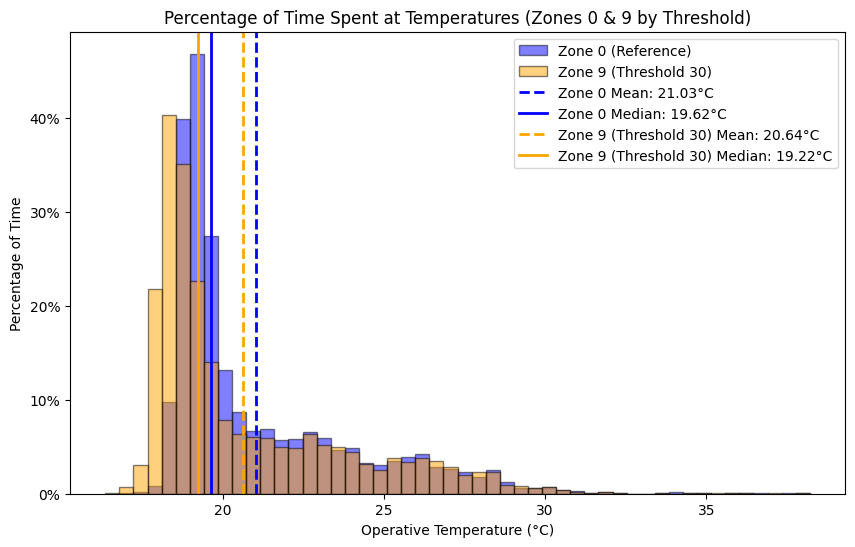

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter DataFrame for case 0 and both zones 0 and 9
df_case_0 = temperature_df[temperature_df['case'] == 0]

# Create lists to store operative temperatures for Zone 0 and for different thresholds in Zone 9
opr_temps_zone_0 = []
opr_temps_zone_9_by_threshold = {30: []}

# Iterate over rows in the DataFrame
for index, row in df_case_0.iterrows():
    opr_temps = row['opr_temperature_distribution']  # Dictionary of room temperatures
    zone = row['zone']
    threshold = row['threshold']

    # For each room in the opr_temperature_distribution, collect the temperatures
    for room, temps in opr_temps.items():
        if zone == 0:
            opr_temps_zone_0.extend(temps)  # Collect for Zone 0
        elif zone == 9 and threshold in opr_temps_zone_9_by_threshold:
            opr_temps_zone_9_by_threshold[threshold].extend(temps)  # Collect by threshold for Zone 9

# Convert the lists of temperatures to flat lists (if needed) and calculate min/max temperatures
all_temperatures = opr_temps_zone_0 + [temp for temps in opr_temps_zone_9_by_threshold.values() for temp in temps]
min_temp = min(all_temperatures)
max_temp = max(all_temperatures)

# Calculate mean and median for Zone 0 and Zone 9 (Threshold 30)
mean_zone_0 = pd.Series(opr_temps_zone_0).mean()
median_zone_0 = pd.Series(opr_temps_zone_0).median()
mean_zone_9 = pd.Series(opr_temps_zone_9_by_threshold[30]).mean()
median_zone_9 = pd.Series(opr_temps_zone_9_by_threshold[30]).median()

# Plot the percentage histogram for Zone 0 and Zone 9 by thresholds
plt.figure(figsize=(10, 6))

# Plot the histogram for Zone 0 (reference)
plt.hist(opr_temps_zone_0, bins=50, alpha=0.5, label='Zone 0 (Reference)', color='blue', edgecolor='black', range=(min_temp, max_temp), density=True)

# Plot the histograms for different thresholds in Zone 9
colors = {5: 'red', 10: 'green', 15: 'purple', 30: 'orange'}
for threshold, temps in opr_temps_zone_9_by_threshold.items():
    plt.hist(temps, bins=50, alpha=0.5, label=f'Zone 9 (Threshold {threshold})', color=colors[threshold], edgecolor='black', range=(min_temp, max_temp), density=True)

# Add vertical lines for mean and median for Zone 0
plt.axvline(mean_zone_0, color='blue', linestyle='dashed', linewidth=2, label=f'Zone 0 Mean: {mean_zone_0:.2f}°C')
plt.axvline(median_zone_0, color='blue', linestyle='solid', linewidth=2, label=f'Zone 0 Median: {median_zone_0:.2f}°C')

# Add vertical lines for mean and median for Zone 9 (Threshold 30)
plt.axvline(mean_zone_9, color='orange', linestyle='dashed', linewidth=2, label=f'Zone 9 (Threshold 30) Mean: {mean_zone_9:.2f}°C')
plt.axvline(median_zone_9, color='orange', linestyle='solid', linewidth=2, label=f'Zone 9 (Threshold 30) Median: {median_zone_9:.2f}°C')

# Multiply the density by 100 to convert to percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Add titles and labels
plt.title('Percentage of Time Spent at Temperatures (Zones 0 & 9 by Threshold)')
plt.xlabel('Operative Temperature (°C)')
plt.ylabel('Percentage of Time')

# Add legend to distinguish between the different zones, thresholds, and statistics
plt.legend()

# Show the plot
plt.show()



In [20]:
temperature_df

,case,zone,air_temperature_distribution,opr_temperature_distribution
0,0,0,"{'hall_downstairs': [20.20603287414367, 20.008...","{'hall_downstairs': [19.17095851178541, 19.352..."
1,0,9,"{'hall_downstairs': [20.01359866286451, 20.016...","{'hall_downstairs': [17.97987610955011, 28.392..."
2,0,9,"{'hall_downstairs': [20.00740140583124, 22.584...","{'hall_downstairs': [18.08399162893303, 22.323..."
3,0,9,"{'hall_downstairs': [20.06557186584034, 26.002...","{'hall_downstairs': [18.59821552319588, 21.860..."
4,0,9,"{'hall_downstairs': [19.16356105045652, 25.753...","{'hall_downstairs': [22.02308180780201, 28.261..."


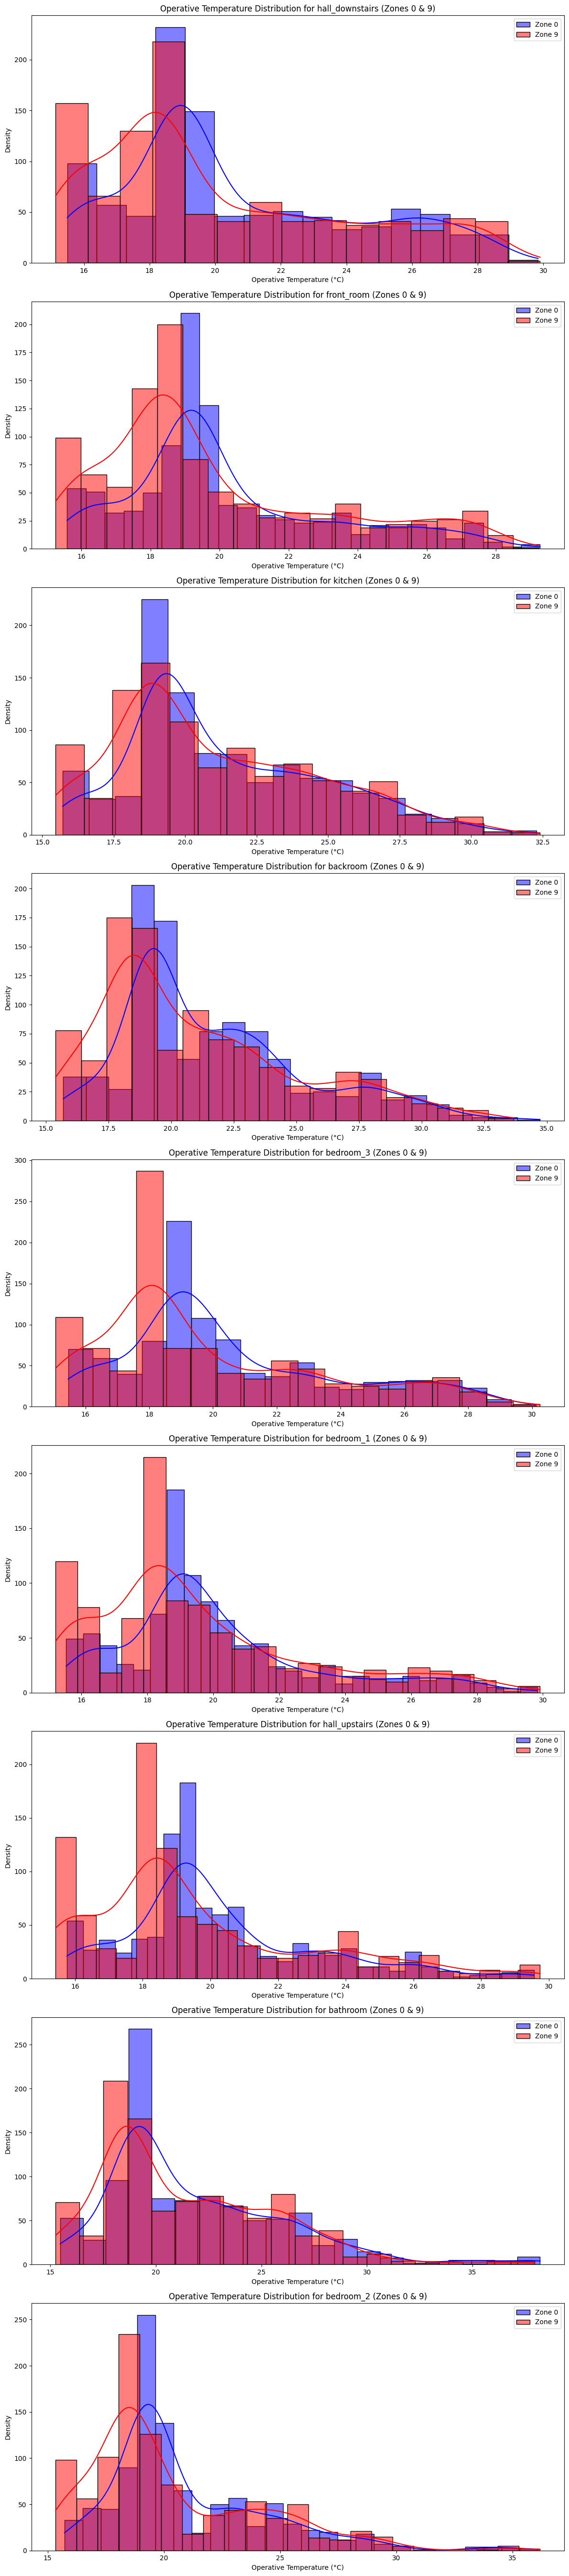

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define room areas
room_areas = {
    'front_room': 14.04,
    'kitchen': 11.34,
    'backroom': 11.34,
    'hall_downstairs': 7.02,
    'bedroom_1': 11.51,
    'bedroom_2': 12.39,
    'bedroom_3': 6.86,
    'bathroom': 7.105,
    'hall_upstairs': 5.88
}

# Calculate the total floor area
total_floor_area = sum(room_areas.values())


# Filter DataFrame for case 0, and then for zones 0 and 9 separately
df_zone_0 = temperature_df[(temperature_df['case'] == 0) & (temperature_df['zone'] == 0)]
df_zone_9 = temperature_df[(temperature_df['case'] == 0) & (temperature_df['zone'] == 9)]

# Extract the unique room names from the first row of the filtered DataFrame
first_row_opr = df_zone_0['opr_temperature_distribution'].iloc[0]
rooms = first_row_opr.keys()

# Create subplots for each room (one subplot per room)
fig, axs = plt.subplots(len(rooms), 1, figsize=(12, 6 * len(rooms)))

# Plot the Distribution with Smooth Line for each room
for i, room in enumerate(rooms):
    # Extract operative temperatures for each room in Zone 0
    opr_temps_zone_0 = [row.get(room, [None]) for row in df_zone_0['opr_temperature_distribution']]
    opr_temps_zone_0 = [temp for sublist in opr_temps_zone_0 for temp in sublist if temp is not None]

    # Extract operative temperatures for each room in Zone 9
    opr_temps_zone_9 = [row.get(room, [None]) for row in df_zone_9['opr_temperature_distribution']]
    opr_temps_zone_9 = [temp for sublist in opr_temps_zone_9 for temp in sublist if temp is not None]

    # Plot Distribution with KDE (smooth line) for Zone 0
    sns.histplot(opr_temps_zone_0, ax=axs[i], label='Zone 0', color='blue', kde=True)

    # Plot Distribution with KDE (smooth line) for Zone 9
    sns.histplot(opr_temps_zone_9, ax=axs[i], label='Zone 9', color='red', kde=True)

    # Set titles and labels
    axs[i].set_title(f'Operative Temperature Distribution for {room} (Zones 0 & 9)')
    axs[i].set_xlabel('Operative Temperature (°C)')
    axs[i].set_ylabel('Density')

    # Add a legend to distinguish between the zones
    axs[i].legend()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


In [9]:
temperature_df

,case,zone,air_temperature_distribution,opr_temperature_distribution
0,0,0,"{'hall_downstairs': [20.20603287414367, 20.008...","{'hall_downstairs': [19.17095851178541, 19.352..."
1,0,9,"{'hall_downstairs': [22.73215573310844, 22.965...","{'hall_downstairs': [17.96142377118037, 18.231..."


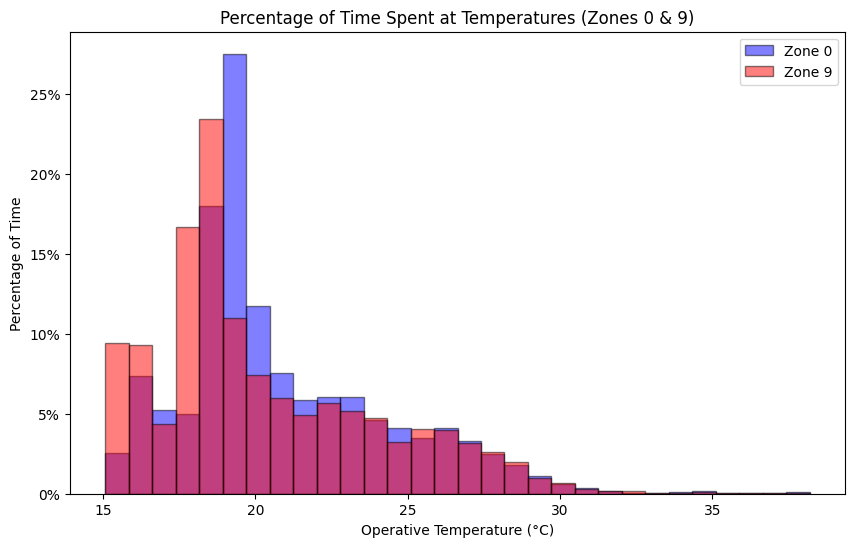

In [14]:
import matplotlib.pyplot as plt

# Filter DataFrame for case 0
df_case_0 = temperature_df[temperature_df['case'] == 0]

# Create lists to store temperatures for Zone 0 and Zone 9 separately
temps_zone_0 = []
temps_zone_9 = []

for index, row in df_case_0.iterrows():
    zone = row['zone']
    opr_temps = row['opr_temperature_distribution']  # Dictionary of room temperatures

    # For each room in the opr_temperature_distribution, collect the temperatures
    for room, temps in opr_temps.items():
        if zone == 0:
            temps_zone_0.extend(temps)
        elif zone == 9:
            temps_zone_9.extend(temps)

# Determine the min and max temperatures for setting the x-axis range
all_temperatures = temps_zone_0 + temps_zone_9
min_temp = min(all_temperatures)
max_temp = max(all_temperatures)

# Plot the percentage histogram for Zone 0 and Zone 9
plt.figure(figsize=(10, 6))

# Plot the percentage histogram for Zone 0
plt.hist(temps_zone_0, bins=30, alpha=0.5, label='Zone 0', color='blue', edgecolor='black', range=(min_temp, max_temp), density=True)

# Plot the percentage histogram for Zone 9
plt.hist(temps_zone_9, bins=30, alpha=0.5, label='Zone 9', color='red', edgecolor='black', range=(min_temp, max_temp), density=True)

# Multiply the density by 100 to convert to percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Add titles and labels
plt.title('Percentage of Time Spent at Temperatures (Zones 0 & 9)')
plt.xlabel('Operative Temperature (°C)')
plt.ylabel('Percentage of Time')

# Add legend to distinguish between the two zones
plt.legend()

# Show the plot
plt.show()


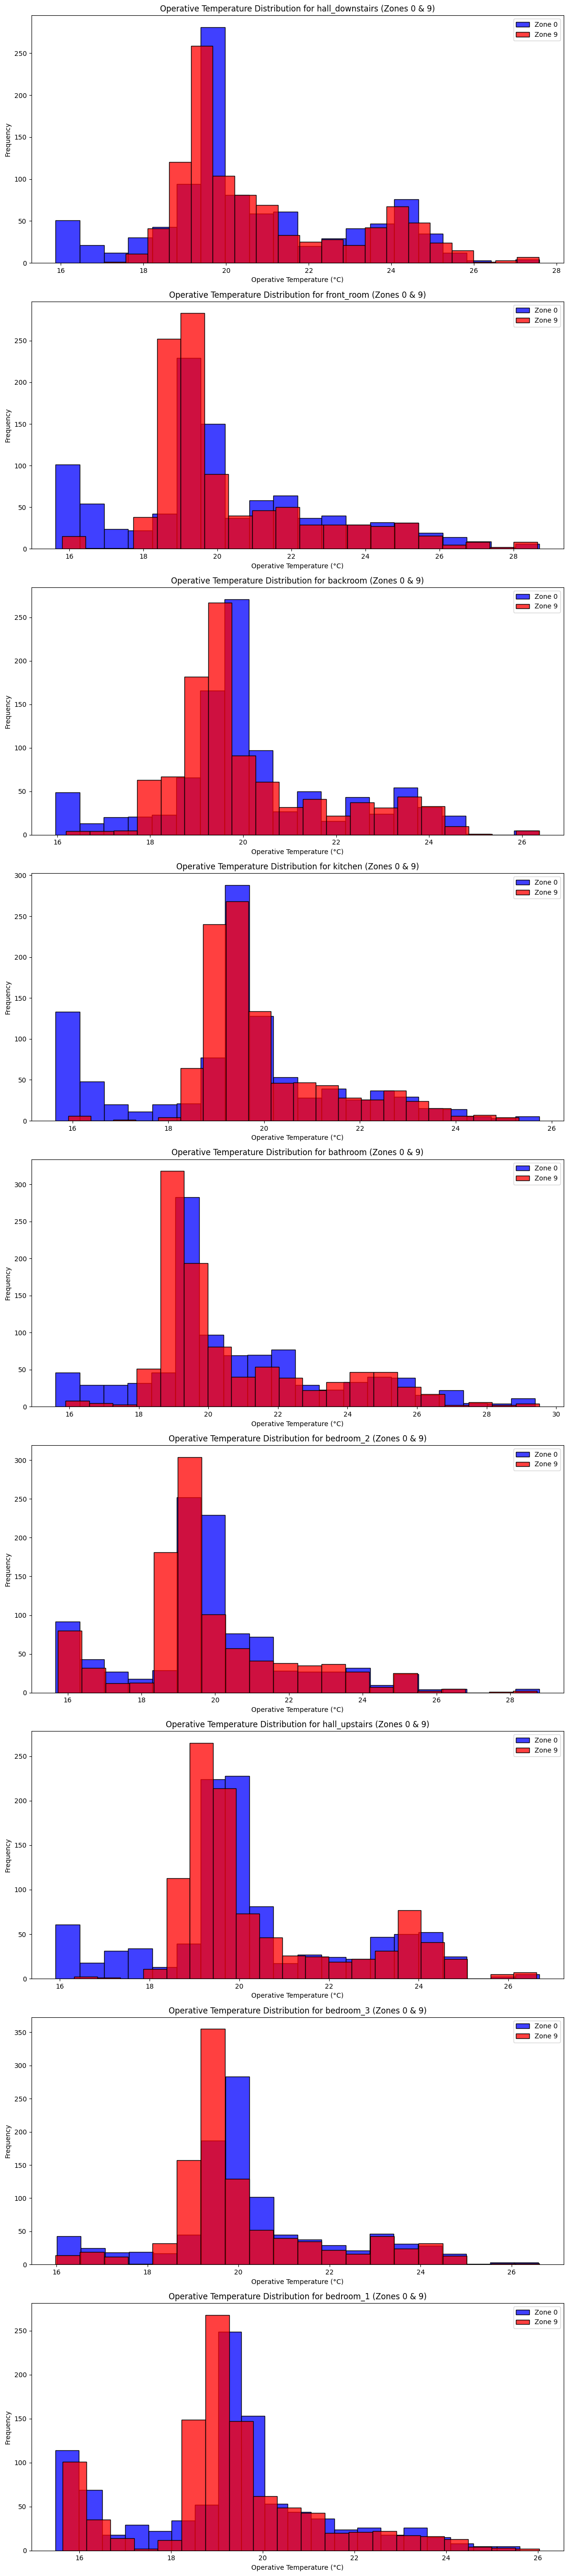

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter DataFrame for case 0, and then for zones 0 and 9 separately
df_zone_0 = temperature_df[(temperature_df['case'] == 0) & (temperature_df['zone'] == 0)]
df_zone_9 = temperature_df[(temperature_df['case'] == 0) & (temperature_df['zone'] == 9)]

# Extract the unique room names from the first row of the filtered DataFrame
first_row_opr = df_zone_0['opr_temperature_distribution'].iloc[0]
rooms = first_row_opr.keys()

# Create subplots for each room (one subplot per room)
fig, axs = plt.subplots(len(rooms), 1, figsize=(12, 6 * len(rooms)))

# Plot the Distribution for each room
for i, room in enumerate(rooms):
    # Extract operative temperatures for each room in Zone 0
    opr_temps_zone_0 = [row.get(room, [None]) for row in df_zone_0['opr_temperature_distribution']]
    opr_temps_zone_0 = [temp for sublist in opr_temps_zone_0 for temp in sublist if temp is not None]

    # Extract operative temperatures for each room in Zone 9
    opr_temps_zone_9 = [row.get(room, [None]) for row in df_zone_9['opr_temperature_distribution']]
    opr_temps_zone_9 = [temp for sublist in opr_temps_zone_9 for temp in sublist if temp is not None]

    # Plot Distribution (Histogram) for Zone 0
    sns.histplot(opr_temps_zone_0, ax=axs[i], label='Zone 0', color='blue', kde=False, bins=20)

    # Plot Distribution (Histogram) for Zone 9
    sns.histplot(opr_temps_zone_9, ax=axs[i], label='Zone 9', color='red', kde=False, bins=20)

    # Set titles and labels
    axs[i].set_title(f'Operative Temperature Distribution for {room} (Zones 0 & 9)')
    axs[i].set_xlabel('Operative Temperature (°C)')
    axs[i].set_ylabel('Frequency')

    # Add a legend to distinguish between the zones
    axs[i].legend()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


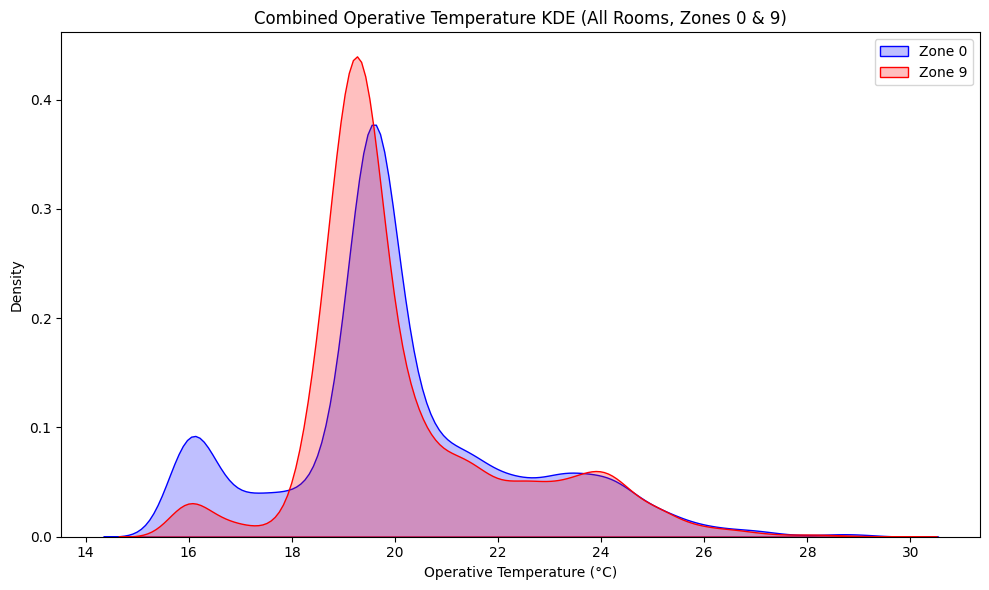

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter DataFrame for case 0, and then for zones 0 and 9 separately
df_zone_0 = temperature_df[(temperature_df['case'] == 0) & (temperature_df['zone'] == 0)]
df_zone_9 = temperature_df[(temperature_df['case'] == 0) & (temperature_df['zone'] == 9)]

# Combine operative temperatures for all rooms in Zone 0
opr_temps_zone_0 = []
for row in df_zone_0['opr_temperature_distribution']:
    for room, temps in row.items():
        opr_temps_zone_0.extend(temps)

# Combine operative temperatures for all rooms in Zone 9
opr_temps_zone_9 = []
for row in df_zone_9['opr_temperature_distribution']:
    for room, temps in row.items():
        opr_temps_zone_9.extend(temps)

# Create a KDE plot comparing all rooms in Zone 0 vs Zone 9
plt.figure(figsize=(10, 6))

# KDE for Zone 0
sns.kdeplot(opr_temps_zone_0, fill=True, label='Zone 0', color='blue')

# KDE for Zone 9
sns.kdeplot(opr_temps_zone_9, fill=True, label='Zone 9', color='red')

# Set plot labels and title
plt.title('Combined Operative Temperature KDE (All Rooms, Zones 0 & 9)')
plt.xlabel('Operative Temperature (°C)')
plt.ylabel('Density')

# Add a legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [18]:
# Filter DataFrame for case 0, and then for zones 0 and 9 separately
df_zone_0 = temperature_df[(temperature_df['case'] == 0) & (temperature_df['zone'] == 0)]
df_zone_9 = temperature_df[(temperature_df['case'] == 0) & (temperature_df['zone'] == 9)]

# Combine operative temperatures for all rooms in Zone 0
opr_temps_zone_0 = []
for row in df_zone_0['opr_temperature_distribution']:
    for room, temps in row.items():
        opr_temps_zone_0.extend(temps)

# Combine operative temperatures for all rooms in Zone 9
opr_temps_zone_9 = []
for row in df_zone_9['opr_temperature_distribution']:
    for room, temps in row.items():
        opr_temps_zone_9.extend(temps)

# Calculate the percentage of temperatures below 20°C for Zone 0
below_20_zone_0 = [temp for temp in opr_temps_zone_0 if temp < 20]
percentage_below_20_zone_0 = len(below_20_zone_0) / len(opr_temps_zone_0) * 100

# Calculate the percentage of temperatures below 20°C for Zone 9
below_20_zone_9 = [temp for temp in opr_temps_zone_9 if temp < 20]
percentage_below_20_zone_9 = len(below_20_zone_9) / len(opr_temps_zone_9) * 100

# Calculate the difference in percentage between Zone 0 and Zone 9
percentage_difference = percentage_below_20_zone_0 - percentage_below_20_zone_9

# Output the results
print(f"Zone 0: {percentage_below_20_zone_0:.2f}% of the time spent below 20°C")
print(f"Zone 9: {percentage_below_20_zone_9:.2f}% of the time spent below 20°C")
print(f"Difference: {percentage_difference:.2f}% more time spent below 20°C in Zone 0")


Zone 0: 61.74% of the time spent below 20°C
Zone 9: 64.54% of the time spent below 20°C
Difference: -2.80% more time spent below 20°C in Zone 0


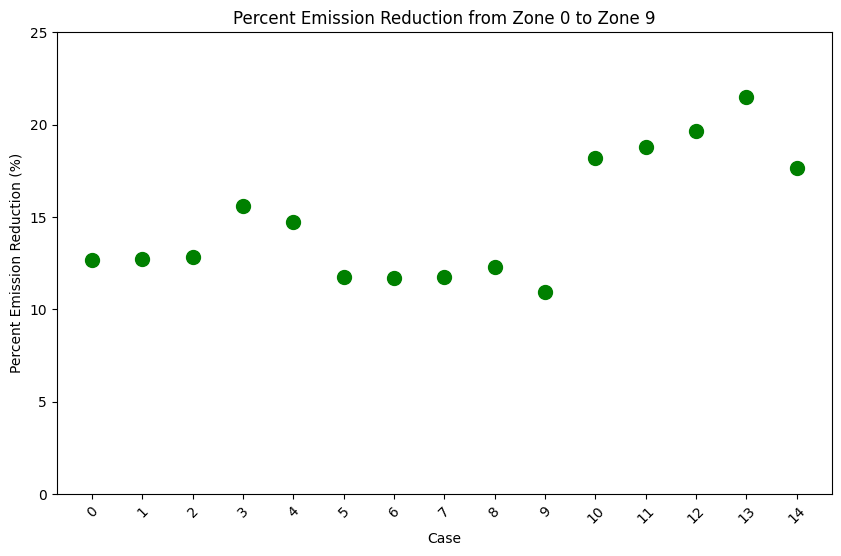

In [21]:
# Calculate percent emission reduction from zone 0 to zone 9
emission_reduction_data = []

for rep in results_df['case'].unique():
    zone_0_emissions = results_df.loc[(results_df['case'] == rep) & (results_df['zone'] == 0), 'mean_episode_emissions']
    zone_9_emissions = results_df.loc[(results_df['case'] == rep) & (results_df['zone'] == 9), 'mean_episode_emissions']

    if not zone_0_emissions.empty and not zone_9_emissions.empty:
        reduction = ((zone_0_emissions.values[0] - zone_9_emissions.values[0]) / zone_0_emissions.values[0]) * 100
        emission_reduction_data.append({'case': rep, 'percent_reduction': reduction})



reduction_df = pd.DataFrame(emission_reduction_data)

# Filter out H28 for scatter plotting and create a copy
scatter_df = reduction_df.copy()

# Convert reps to categorical for proper x-tick ordering
scatter_df['case'] = pd.Categorical(scatter_df['case'], categories=sorted(scatter_df['case'].unique()), ordered=True)
scatter_df['rep_num'] = scatter_df['case'].cat.codes   # Start numbering from 0

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(scatter_df['rep_num'], scatter_df['percent_reduction'], color='green', s=100)
plt.xlabel('Case')
plt.xticks(ticks=scatter_df['rep_num'], labels=scatter_df['case'], rotation=45)
plt.ylim(0, 25)
plt.ylabel('Percent Emission Reduction (%)')
plt.title('Percent Emission Reduction from Zone 0 to Zone 9')
plt.show()


In [1]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt

dir_path = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/synthetic_occupancy_test/results'
files = [f for f in os.listdir(dir_path) if f.endswith('.json')]

results_data = []
temperature_data = []

for file in files:
    with open(os.path.join(dir_path, file), 'r') as f:
        data = json.load(f)
        rep_number = int(file.split('rep_')[1].split('_')[0])
        zone_number = int(file.split('zone_')[1].split('_')[0])

        results_data.append({
            'rep': rep_number,
            'zone': zone_number,
            'mean_episode_reward': data.get('eval/mean_episode_reward'),
            'mean_episode_emissions_reward': data.get('eval/mean_episode_emissions_reward'),
            'mean_episode_comfort_reward': data.get('eval/mean_episode_comfort_reward'),
            'mean_episode_air_quality_reward': data.get('eval/mean_episode_air_quality_reward'),
            'mean_episode_emissions': data.get('eval/mean_episode_emissions'),
            'mean_episode_ndt_t_violations': json.dumps(data.get('eval/mean_episode_ndt_t_violations')),
            'mean_episode_ndt_aq_violations': json.dumps(data.get('eval/mean_episode_ndt_aq_violations')),
            'mean_episode_heating_degree_days': json.dumps(data.get('eval/mean_episode_heating_degree_days')),
            'mean_episode_heating_service_degree_days': json.dumps(data.get('eval/mean_episode_heating_service_degree_days')),
            'mean_episode_max_heating_service_degree_days': json.dumps(data.get('eval/mean_episode_max_heating_service_degree_days')),
            'mean_episode_heating_beyond_comfort_degree_days': json.dumps(data.get('eval/mean_episode_heating_beyond_comfort_degree_days')),
            'mean_episode_violation_degree_days': data.get('eval/mean_episode_violation_degree_days'),
            'mean_episode_violation_ppm_days': json.dumps(data.get('eval/mean_episode_violation_ppm_days')),
            'mean_episode_cost': data.get('eval/mean_episode_cost'),
            'mean_episode_gas_cost': data.get('eval/mean_episode_gas_cost'),
            'mean_episode_electricity_cost': data.get('eval/mean_episode_electricity_cost'),
            'mean_episode_electricity_surplus': data.get('eval/mean_episode_electricity_surplus'),
            'mean_episode_cost_reward': data.get('eval/mean_episode_cost_reward')
        })

        temperature_data.append({
            'rep': rep_number,
            'zone': zone_number,
            'air_temperature_distribution': json.dumps(data.get('eval/air_temperature_distribution')),
            'opr_temperature_distribution': json.dumps(data.get('eval/opr_temperature_distribution'))
        })

results_df = pd.DataFrame(results_data)
temperature_df = pd.DataFrame(temperature_data)


<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


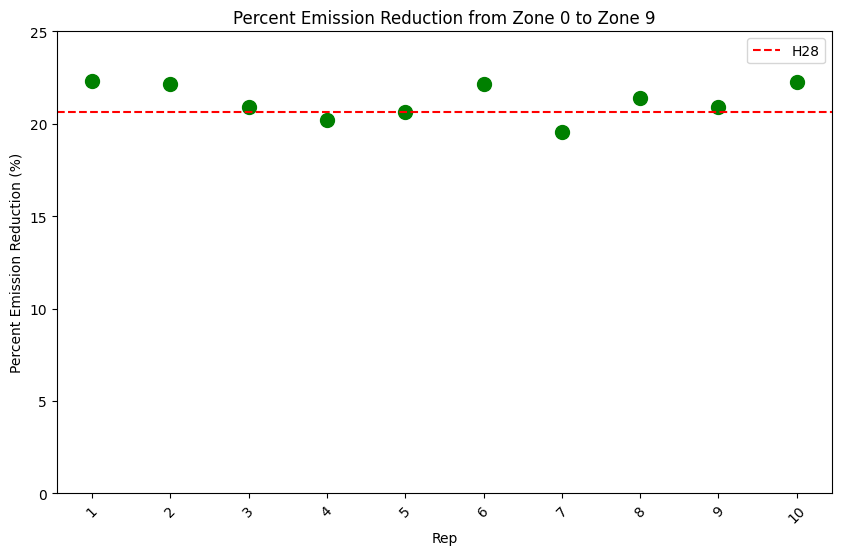

In [8]:
# Calculate percent emission reduction from zone 0 to zone 9
emission_reduction_data = []

for rep in results_df['rep'].unique():
    zone_0_emissions = results_df.loc[(results_df['rep'] == rep) & (results_df['zone'] == 0), 'mean_episode_emissions']
    zone_9_emissions = results_df.loc[(results_df['rep'] == rep) & (results_df['zone'] == 9), 'mean_episode_emissions']

    if not zone_0_emissions.empty and not zone_9_emissions.empty:
        reduction = ((zone_0_emissions.values[0] - zone_9_emissions.values[0]) / zone_0_emissions.values[0]) * 100
        emission_reduction_data.append({'rep': 'H28' if rep == 0 else rep, 'percent_reduction': reduction})

reduction_df = pd.DataFrame(emission_reduction_data)

# Extract H28 value for horizontal line
h28_value = reduction_df.loc[reduction_df['rep'] == 'H28', 'percent_reduction'].values[0]

# Filter out H28 for scatter plotting and create a copy
scatter_df = reduction_df[reduction_df['rep'] != 'H28'].copy()

# Convert reps to categorical for proper x-tick ordering
scatter_df['rep'] = pd.Categorical(scatter_df['rep'], categories=sorted(scatter_df['rep'].unique()), ordered=True)
scatter_df['rep_num'] = scatter_df['rep'].cat.codes + 1  # Start numbering from 1

# Plotting
plt.figure(figsize=(10, 6))
plt.axhline(y=h28_value, color='red', linestyle='--', label='H28')  # Horizontal line for H28
plt.scatter(scatter_df['rep_num'], scatter_df['percent_reduction'], color='green', s=100)
plt.xlabel('Rep')
plt.xticks(ticks=scatter_df['rep_num'], labels=scatter_df['rep'], rotation=45)
plt.ylim(0, 25)
plt.ylabel('Percent Emission Reduction (%)')
plt.title('Percent Emission Reduction from Zone 0 to Zone 9')
plt.legend()
plt.show()


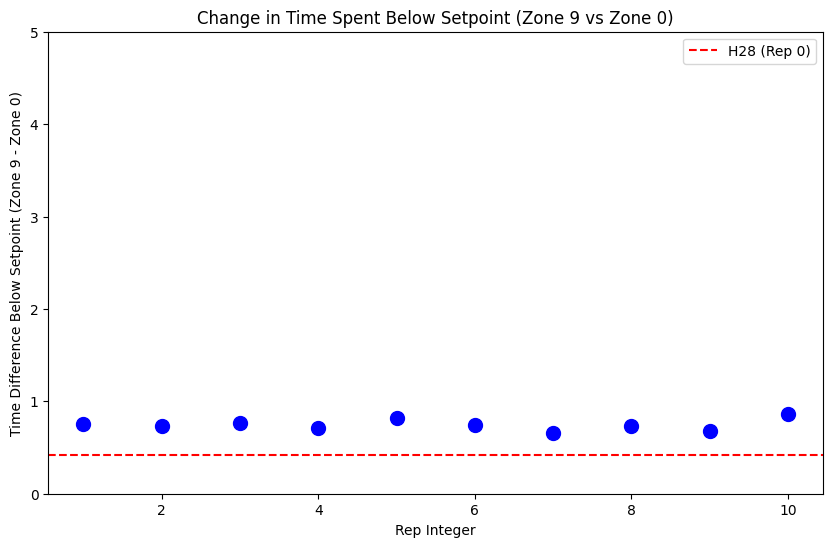

In [38]:
import pandas as pd
import json
import matplotlib.pyplot as plt

setpoint = 20  # Setpoint temperature

# Define room areas
room_areas = {
    'front_room': 14.04,
    'kitchen': 11.34,
    'backroom': 11.34,
    'hall_downstairs': 7.02,
    'bedroom_1': 11.51,
    'bedroom_2': 12.39,
    'bedroom_3': 6.86,
    'bathroom': 7.105,
    'hall_upstairs': 5.88
}

# Calculate the total floor area
total_floor_area = sum(room_areas.values())

# Function to calculate the total time spent below setpoint considering room sizes
def calculate_total_time_below_setpoint(distribution_1, distribution_2, setpoint):
    total_time_below_setpoint = []

    for room in distribution_1.keys():
        percentages_1 = distribution_1[room]
        percentages_2 = distribution_2[room]

        temp_df_1 = pd.DataFrame(list(percentages_1.items()), columns=['Temperature', 'Percentage'])
        temp_df_1['Temperature'] = pd.to_numeric(temp_df_1['Temperature'])
        temp_df_1["Percentage"] *= (room_areas[room] / total_floor_area)  # Adjust for room size
        temp_df_1_percentage = temp_df_1[temp_df_1["Temperature"] < setpoint]["Percentage"].sum()

        temp_df_2 = pd.DataFrame(list(percentages_2.items()), columns=['Temperature', 'Percentage'])
        temp_df_2['Temperature'] = pd.to_numeric(temp_df_2['Temperature'])
        temp_df_2["Percentage"] *= (room_areas[room] / total_floor_area)  # Adjust for room size
        temp_df_2_percentage = temp_df_2[temp_df_2["Temperature"] < setpoint]["Percentage"].sum()

        change = temp_df_2_percentage - temp_df_1_percentage
        total_time_below_setpoint.append(change)

    return sum(total_time_below_setpoint) / len(total_time_below_setpoint)

# Collecting differences for each rep
time_differences = []

for rep in temperature_df['rep'].unique():
    zone_0_dist = temperature_df.loc[(temperature_df['rep'] == rep) & (temperature_df['zone'] == 0), 'opr_temperature_distribution'].values[0]
    zone_9_dist = temperature_df.loc[(temperature_df['rep'] == rep) & (temperature_df['zone'] == 9), 'opr_temperature_distribution'].values[0]

    if zone_0_dist and zone_9_dist:
        zone_0_dict = json.loads(zone_0_dist)
        zone_9_dict = json.loads(zone_9_dist)

        time_difference = calculate_total_time_below_setpoint(zone_0_dict, zone_9_dict, setpoint)
        time_differences.append({'rep': rep, 'time_difference': time_difference})

# Creating a DataFrame from the results
opr_time_diff_df = pd.DataFrame(time_differences)

# Extract H28 value for horizontal line and exclude from scatter
opr_h28_value = opr_time_diff_df.loc[opr_time_diff_df['rep'] == 0, 'time_difference'].values[0]
opr_scatter_df = opr_time_diff_df[opr_time_diff_df['rep'] != 0]

# Plotting the time difference below setpoint
plt.figure(figsize=(10, 6))
plt.axhline(y=opr_h28_value, color='red', linestyle='--', label='H28 (Rep 0)')
plt.scatter(opr_scatter_df['rep'], opr_scatter_df['time_difference'], color='blue', s=100)
plt.xlabel('Rep Integer')
plt.ylabel('Time Difference Below Setpoint (Zone 9 - Zone 0)')
plt.title('Change in Time Spent Below Setpoint (Zone 9 vs Zone 0)')
plt.ylim(0, 5)  # Adjusted y-limit for positive and negative values
plt.legend()
plt.show()


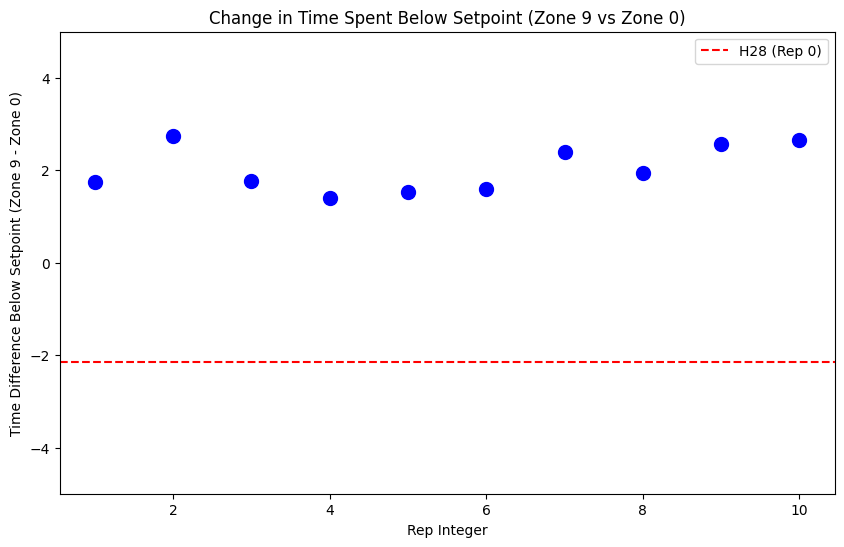

In [39]:
import pandas as pd
import json
import matplotlib.pyplot as plt

setpoint = 20  # Setpoint temperature

# Define room areas
room_areas = {
    'front_room': 14.04,
    'kitchen': 11.34,
    'backroom': 11.34,
    'hall_downstairs': 7.02,
    'bedroom_1': 11.51,
    'bedroom_2': 12.39,
    'bedroom_3': 6.86,
    'bathroom': 7.105,
    'hall_upstairs': 5.88
}

# Calculate the total floor area
total_floor_area = sum(room_areas.values())

# Function to calculate the total time spent below setpoint considering room sizes
def calculate_total_time_below_setpoint(distribution_1, distribution_2, setpoint):
    total_time_below_setpoint = []

    for room in distribution_1.keys():
        percentages_1 = distribution_1[room]
        percentages_2 = distribution_2[room]

        temp_df_1 = pd.DataFrame(list(percentages_1.items()), columns=['Temperature', 'Percentage'])
        temp_df_1['Temperature'] = pd.to_numeric(temp_df_1['Temperature'])
        temp_df_1["Percentage"] *= (room_areas[room] / total_floor_area)  # Adjust for room size
        temp_df_1_percentage = temp_df_1[temp_df_1["Temperature"] < setpoint]["Percentage"].sum()

        temp_df_2 = pd.DataFrame(list(percentages_2.items()), columns=['Temperature', 'Percentage'])
        temp_df_2['Temperature'] = pd.to_numeric(temp_df_2['Temperature'])
        temp_df_2["Percentage"] *= (room_areas[room] / total_floor_area)  # Adjust for room size
        temp_df_2_percentage = temp_df_2[temp_df_2["Temperature"] < setpoint]["Percentage"].sum()

        change = temp_df_2_percentage - temp_df_1_percentage
        total_time_below_setpoint.append(change)

    return sum(total_time_below_setpoint) / len(total_time_below_setpoint)

# Collecting differences for each rep
time_differences = []

for rep in temperature_df['rep'].unique():
    zone_0_dist = temperature_df.loc[(temperature_df['rep'] == rep) & (temperature_df['zone'] == 0), 'air_temperature_distribution'].values[0]
    zone_9_dist = temperature_df.loc[(temperature_df['rep'] == rep) & (temperature_df['zone'] == 9), 'air_temperature_distribution'].values[0]

    if zone_0_dist and zone_9_dist:
        zone_0_dict = json.loads(zone_0_dist)
        zone_9_dict = json.loads(zone_9_dist)

        time_difference = calculate_total_time_below_setpoint(zone_0_dict, zone_9_dict, setpoint)
        time_differences.append({'rep': rep, 'time_difference': time_difference})

# Creating a DataFrame from the results
time_diff_df = pd.DataFrame(time_differences)

# Extract H28 value for horizontal line and exclude from scatter
h28_value = time_diff_df.loc[time_diff_df['rep'] == 0, 'time_difference'].values[0]
scatter_df = time_diff_df[time_diff_df['rep'] != 0]

# Plotting the time difference below setpoint
plt.figure(figsize=(10, 6))
plt.axhline(y=h28_value, color='red', linestyle='--', label='H28 (Rep 0)')
plt.scatter(scatter_df['rep'], scatter_df['time_difference'], color='blue', s=100)
plt.xlabel('Rep Integer')
plt.ylabel('Time Difference Below Setpoint (Zone 9 - Zone 0)')
plt.title('Change in Time Spent Below Setpoint (Zone 9 vs Zone 0)')
plt.ylim(-5, 5)  # Adjusted y-limit for positive and negative values
plt.legend()
plt.show()


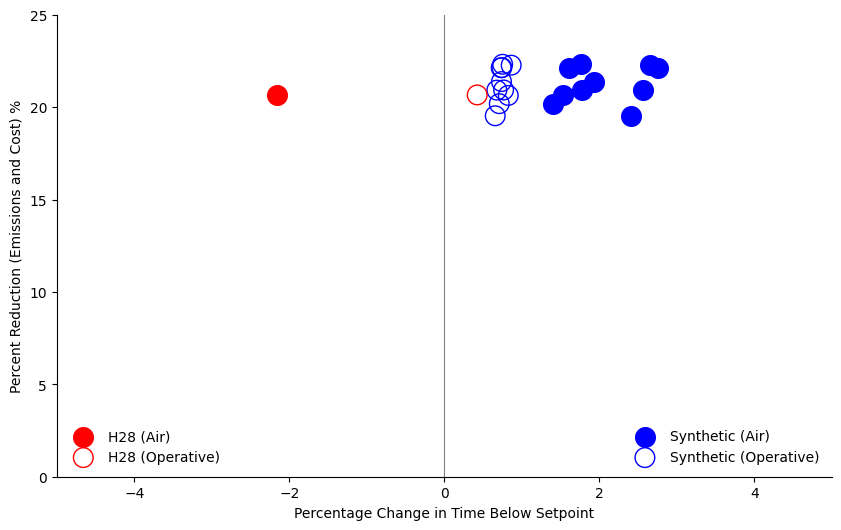

In [68]:
# Update rep 0 in both DataFrames to 'H28'
time_diff_df['rep'] = time_diff_df['rep'].replace(0, 'H28')
opr_time_diff_df['rep'] = opr_time_diff_df['rep'].replace(0, 'H28')

# Merging the two DataFrames on 'rep'
combined_df = pd.merge(time_diff_df, opr_time_diff_df, on='rep', suffixes=('_time_diff', '_opr'))

# Merging the combined DataFrame with reduction_df to get percent_reduction
merged_df = pd.merge(combined_df, reduction_df, on='rep')

# Separate H28 for distinct visualisation
h28_data = merged_df[merged_df['rep'] == 'H28']
other_reps_data = merged_df[merged_df['rep'] != 'H28']

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot for `time_difference` for all synthetic reps (solid circle)
synthetic_air = ax.scatter(other_reps_data['time_difference_time_diff'], other_reps_data['percent_reduction'],
                           color='blue', s=200, label='Air (Synthetic)', marker='o')

# Scatter plot for `time_difference` for all synthetic air (hollow circle)
synthetic_opr = ax.scatter(other_reps_data['time_difference_opr'], other_reps_data['percent_reduction'],
                           facecolors='none', edgecolors='blue', s=200, label='Operative (Synthetic)', marker='o')

# Highlight `time_difference` for H28 (solid triangle)
h28_air = ax.scatter(h28_data['time_difference_time_diff'], h28_data['percent_reduction'],
                     color='red', s=200, label='Air (H28)', marker='o')

# Highlight `time_difference` for H28 air (hollow triangle)
h28_opr = ax.scatter(h28_data['time_difference_opr'], h28_data['percent_reduction'],
                     facecolors='none', edgecolors='red', s=200, label='Operative (H28)', marker='o')

# Labels and titles
ax.set_xlabel('Percentage Change in Time Below Setpoint')
ax.set_ylabel('Percent Reduction (Emissions and Cost) %')

# Optional reference line
ax.axvline(0, color='grey', linestyle='-', linewidth=0.8)

# Remove the top and right-hand side grid lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set limits for the plot
ax.set_xlim(-5, 5)
ax.set_ylim(0, 25)

# Create first legend for H28 entries

# Add the first legend manually to the axes
legend1 = ax.legend([h28_air, h28_opr], ['H28 (Air)', 'H28 (Operative)'], loc='lower left', frameon=False)
ax.add_artist(legend1)

# Create second legend for synthetic entries
ax.legend([synthetic_air, synthetic_opr], ['Synthetic (Air)', 'Synthetic (Operative)'], loc='lower right', frameon=False)

plt.show()
